# Quantization Aware Training + Knowledge Distillation 
## PyTorch -> TfLite

In [1]:
import os
import torch

from model_compression.src.utils import load_data, process_callbacks
from model_compression.src.converters.to_tflite import convert_pytorch_model_to_tflite
from model_compression.src.train.knowledge_distillation import train_qat_kd
from model_compression.src.utils.logging_setup import configure_logging

2025-04-24 19:00:01.322186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 19:00:01.330010: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745535601.338994   10534 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745535601.341732   10534 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745535601.349383   10534 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-04-24 19:00:02,740 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-24 19:00:02,741 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-24 19:00:02,741 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-24 19:00:02,741 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-24 19:00:02,742 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-24 19:00:02,743 preprocessi

Model prepared using Export Mode QAT.


Train Epoch 1/1: 100%|██████████| 917/917 [03:03<00:00,  5.01it/s, loss=0.8443]
[INFO 2025-04-24 19:03:09,972 knowledge_distillation.py:354] Train Loss: 0.8443
[INFO 2025-04-24 19:03:09,973 knowledge_distillation.py:355] Train Metrics: accuracy: 0.6956, recall: 0.5038, precision: 0.5908, f1-score: 0.5276, auc-score: 0.9403
[INFO 2025-04-24 19:03:09,976 eval.py:160] Starting inference...
Inference Progress: 100%|██████████| 115/115 [00:18<00:00,  6.19it/s]
[INFO 2025-04-24 19:03:28,789 eval.py:188] Inference complete.
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[INFO 2025-04-24 19:03:28,822 knowledge_distillation.py:261] Val Loss: 0.7790
[INFO 2025-04-24 19:03:28,823 knowledge_distillation.p

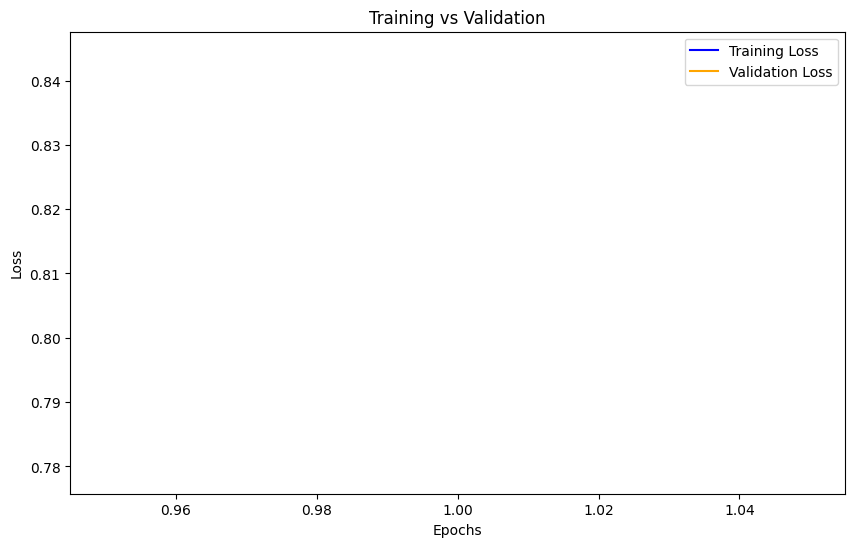

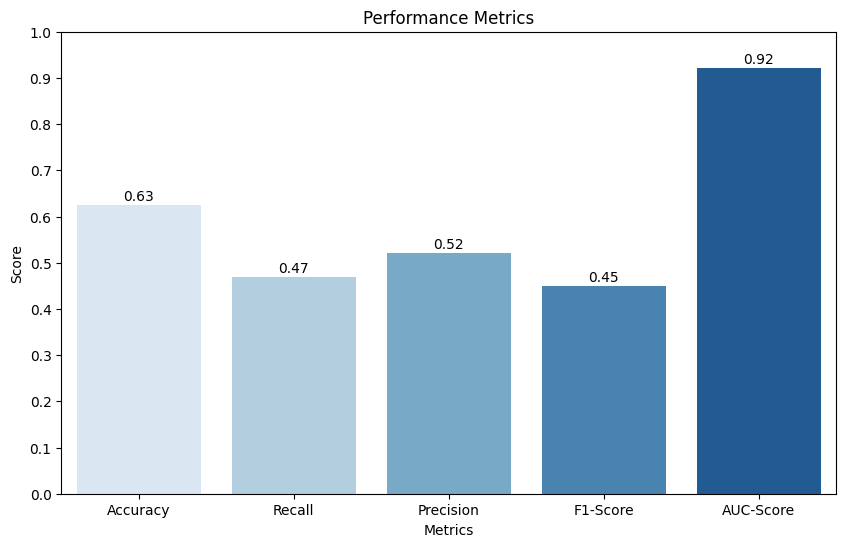

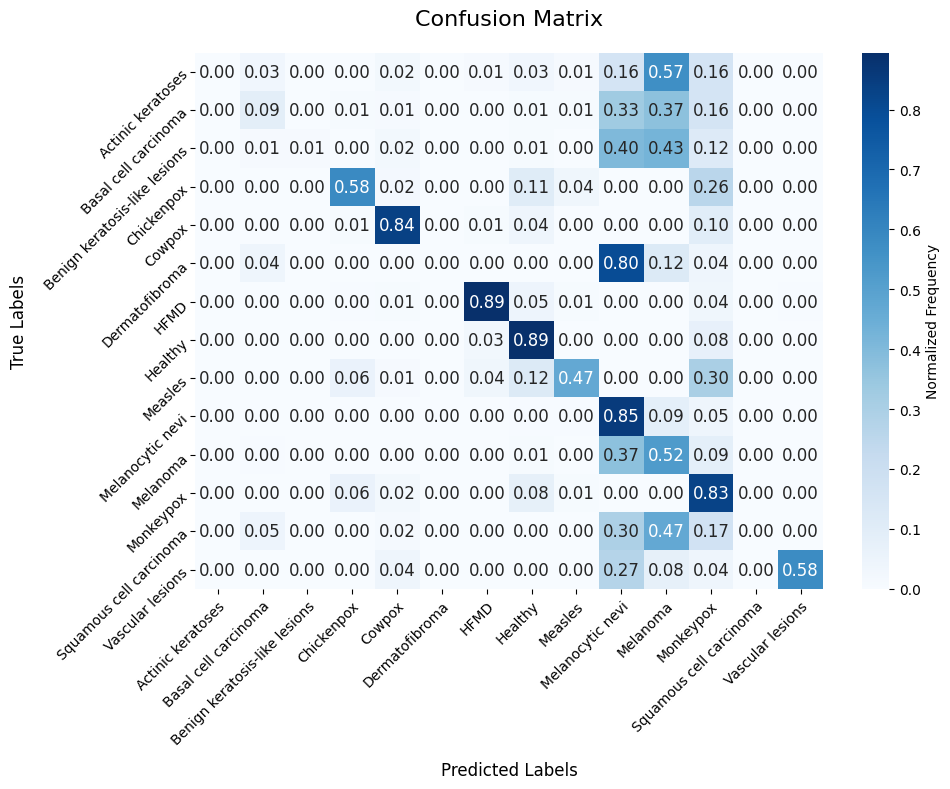

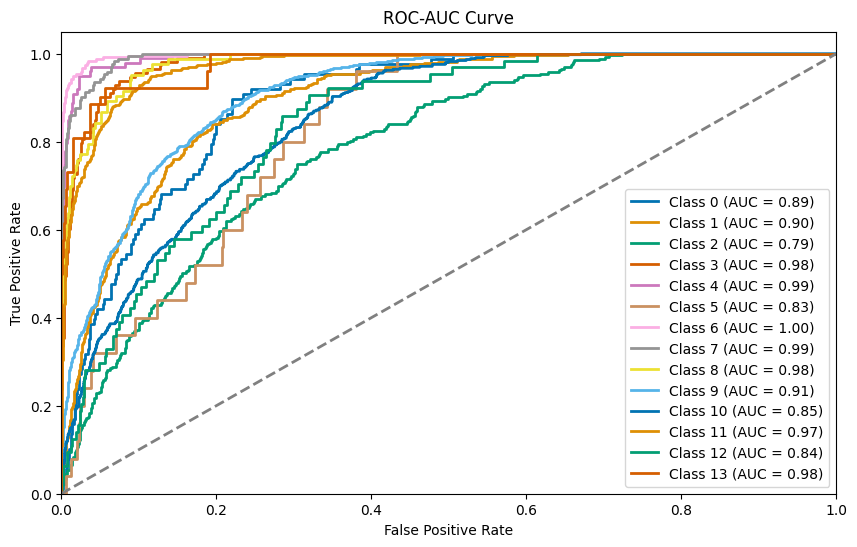

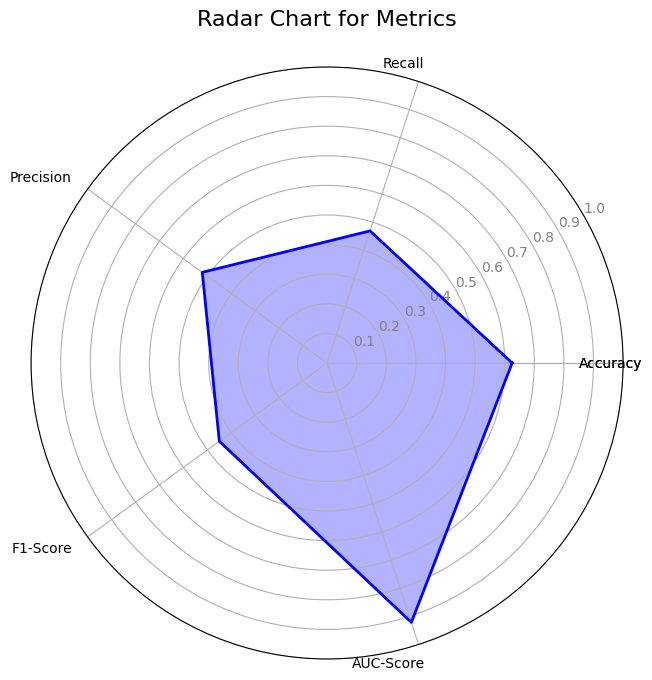

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_qat_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        epochs=epochs,
                                        criterion = criterion,
                                        optimizer = optimizer,
                                        callbacks=CALLBACKS,
                                        quant_mode="export",
                                        teacher_model_weights=teacher_model_weights,
                                        device=device,
                                )


### 2. Export to TfLite

In [4]:
example_inputs = next(iter(dataloaders['train']))[0]
tflite_path = os.path.join(save_dir, f"{student_model}_qat_kd.tflite")
convert_pytorch_model_to_tflite(quantized_student, (example_inputs,), tflite_path)

[INFO 2025-04-24 19:05:43,161 to_tflite.py:32] Converting PyTorch model to TensorFlow Lite format.
[WARNING 2025-04-24 19:05:43,162 conversion.py:77] Your model is converted in training mode. Please set the module in evaluation mode with `module.eval()` for better on-device performance and compatibility.
[INFO 2025-04-24 19:05:52,276 _jax_lowerings.py:32] Use JAX lowering: aten.permute
[INFO 2025-04-24 19:05:52,283 _jax_lowerings.py:32] Use JAX lowering: aten.clone.default
[INFO 2025-04-24 19:05:52,292 _jax_lowerings.py:32] Use JAX lowering: aten.add.Tensor
[INFO 2025-04-24 19:05:52,296 _jax_lowerings.py:32] Use JAX lowering: aten.hardtanh
[INFO 2025-04-24 19:05:52,865 _jax_lowerings.py:32] Use JAX lowering: aten.mean
[INFO 2025-04-24 19:05:52,870 _jax_lowerings.py:32] Use JAX lowering: aten.view
[INFO 2025-04-24 19:05:52,876 _jax_lowerings.py:32] Use JAX lowering: aten.mm
[INFO 2025-04-24 19:05:52,879 _jax_lowerings.py:32] Use JAX lowering: aten.mul.Tensor
I0000 00:00:1745535952.96104

INFO:tensorflow:Assets written to: /tmp/tmpg29vfql2/assets


[INFO 2025-04-24 19:05:54,355 builder_impl.py:836] Assets written to: /tmp/tmpg29vfql2/assets
W0000 00:00:1745535956.106638   10534 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1745535956.106659   10534 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-04-24 19:05:56.107002: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpg29vfql2
2025-04-24 19:05:56.107827: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-04-24 19:05:56.107831: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpg29vfql2
I0000 00:00:1745535956.116764   10534 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-04-24 19:05:56.118040: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-04-24 19:05:56.190128: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/

ConverterError: /home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/torchvision/models/mobilenetv2.py:170:0: error: 'stablehlo.uniform_dequantize' op operand #0 must be tensor of 2/4/8/16/32-bit uniform quantized signed integer or 2/4/8/16/32-bit uniform quantized unsigned integer or 2/4/8/16/32-bit uniform quantized per axis signed integer or 2/4/8/16/32-bit uniform quantized per axis unsigned integer values, but got 'tensor<14x1280xi8>'


### 3. Model Sizes

In [ ]:
print("qat:", os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print("tflite:", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.tflite") / 1e6)